In [12]:
import numpy as np

# Updated path to include your project folder!
file_path = r"C:\Users\Mihika\OneDrive\Desktop\BlinkConfusion Paper\EEG_data.csv"

# Convert to array
dataset = np.genfromtxt(file_path, delimiter=',', skip_header=1)

# Check number of rows and columns
print(dataset.shape)

(12811, 15)


In [13]:
# Extract the distinct columns we need using slicing

# Raw column will show spikes while blinking, it shows electrical voltage reading directly from the brain electrode
# Predefined label column is for simple video (0) or confusing video (1)
raw_signals = dataset[:, 4]
labels = dataset[:, 13]

# Verify the lengths of our new standalone arrays
print("Total raw data points extracted:", len(raw_signals))
print("Total video labels extracted:", len(labels))

Total raw data points extracted: 12811
Total video labels extracted: 12811


In [14]:
# Establish a standard baseline for normal brainwaves
mean_val = np.mean(raw_signals)
std_val = np.std(raw_signals)

# Define blink threshold (usually 3 standard deviations away from the mean)
blink_threshold = mean_val + (3 * std_val)

print("Average brainwave baseline value:", mean_val)
print("Standard Deviation (normal wave spread):", std_val)
print("Calculated Blink Threshold Voltage:", blink_threshold)

Average brainwave baseline value: 65.57075950355164
Standard Deviation (normal wave spread): 597.8976986053233
Calculated Blink Threshold Voltage: 1859.2638553195216


In [15]:
# Segregate by video type (simple or confusing)
simple_video_signals = raw_signals[labels == 0]
confused_video_signals = raw_signals[labels == 1]

# Print size of each
print("Data points during simple videos:", len(simple_video_signals))
print("Data points during confusing videos:", len(confused_video_signals))

Data points during simple videos: 6662
Data points during confusing videos: 6149


In [16]:
# Count the blinks (sums up all True values above blink threshold)
simple_blinks = np.sum(np.abs(simple_video_signals) > blink_threshold)
confused_blinks = np.sum(np.abs(confused_video_signals) > blink_threshold)

print("Total blinks detected during simple videos:", simple_blinks)
print("Total blinks detected during confusing videos:", confused_blinks)

Total blinks detected during simple videos: 475
Total blinks detected during confusing videos: 495


In [17]:
# Calculating blink rate
simple_blink_rate = simple_blinks / len(simple_video_signals)
confused_blink_rate = confused_blinks / len(confused_video_signals)

print("Simple Video Blink Rate:", simple_blink_rate)
print("Confused Video Blink Rate:", confused_blink_rate)

Simple Video Blink Rate: 0.07129990993695587
Confused Video Blink Rate: 0.08050089445438283


In [18]:
# Do humans blink more when a task is inherently complex/confusing compared to when it is simple?

# Calculating the final percentage increase
percentage_difference = ((confused_blink_rate - simple_blink_rate) / simple_blink_rate) * 100

print(f"Analysis 1 Result: Students blinked {percentage_difference:.2f}% MORE overall during inherently complex videos.")

Analysis 1 Result: Students blinked 12.90% MORE overall during inherently complex videos.


In [19]:
# Do people blink more when a video is inherently complex, or only when they personally feel confused?
# Investigating whether our bodies react to the objective difficulty designed into a task, or our subjective experience of struggling with it.

# Extract the user-defined labels
user_labels = dataset[:, 14]

# Segregate raw signals (0 for not confused, 1 for confused)
calm_moments = raw_signals[user_labels == 0] 
confused_moments = raw_signals[user_labels == 1] 

print("Data points when student felt fine:", len(calm_moments))
print("Data points when student felt confused:", len(confused_moments))

Data points when student felt fine: 6244
Data points when student felt confused: 6567


In [20]:
# Count the blinks 
calm_blinks = np.sum(np.abs(calm_moments) > blink_threshold)
confused_moments_blinks = np.sum(np.abs(confused_moments) > blink_threshold)

# Blink rate calculation
calm_blink_rate = calm_blinks / len(calm_moments)
subjective_confused_blink_rate = confused_moments_blinks / len(confused_moments)

# Calculate the final percentage increase 
subjective_percentage_difference = ((subjective_confused_blink_rate - calm_blink_rate) / calm_blink_rate) * 100

print(f"Felt Fine Blink Rate: {calm_blink_rate:.5f}")
print(f"Felt Confused Blink Rate: {subjective_confused_blink_rate:.5f}")
print()
print(f"Analysis 2 Result: Students blinked {abs(subjective_percentage_difference):.2f}% LESS when they personally FELT confused.")

Felt Fine Blink Rate: 0.08680
Felt Confused Blink Rate: 0.06517

Analysis 2 Result: Students blinked 24.92% LESS when they personally FELT confused.


In [21]:
# Attention vs Meditation State during confusion in Analysis 2:

headset_attention = dataset[:, 2]
headset_meditation = dataset[:, 3]

# Points where the student felt confused
confused_attention_scores = headset_attention[user_labels == 1]
confused_meditation_scores = headset_meditation[user_labels == 1]
total_confused_moments = len(confused_attention_scores)
# length of both scores is equal so we can write either for total's length

# Count how many confused seconds crossed into high activity (> 60, since 60 is the max neutral limit)
high_focus_counts = np.sum(confused_attention_scores > 60)
high_calm_counts = np.sum(confused_meditation_scores > 60)

# Convert these raw counts into definitive timeline percentages
active_focus_percentage = (high_focus_counts / total_confused_moments) * 100
blanking_out_percentage = (high_calm_counts / total_confused_moments) * 100

# Final conclusive project metrics
print()
print("==================================================")
print("   FINAL HYPOTHESIS VERDICT: COGNITIVE PROFILE    ")
print("==================================================")
print(f"Total Subjective Confusion Timeline: {total_confused_moments} data points.")
print(f"Active Focus (High Attention): {active_focus_percentage:.2f}% of the time.")
print(f"Blanking Out (High 'Meditation'): {blanking_out_percentage:.2f}% of the time.")
print("==================================================")


   FINAL HYPOTHESIS VERDICT: COGNITIVE PROFILE    
Total Subjective Confusion Timeline: 6567 data points.
Active Focus (High Attention): 16.22% of the time.
Blanking Out (High 'Meditation'): 27.97% of the time.


Dynamically zooming into rows 7620 to 8120 to capture a real blink spike.


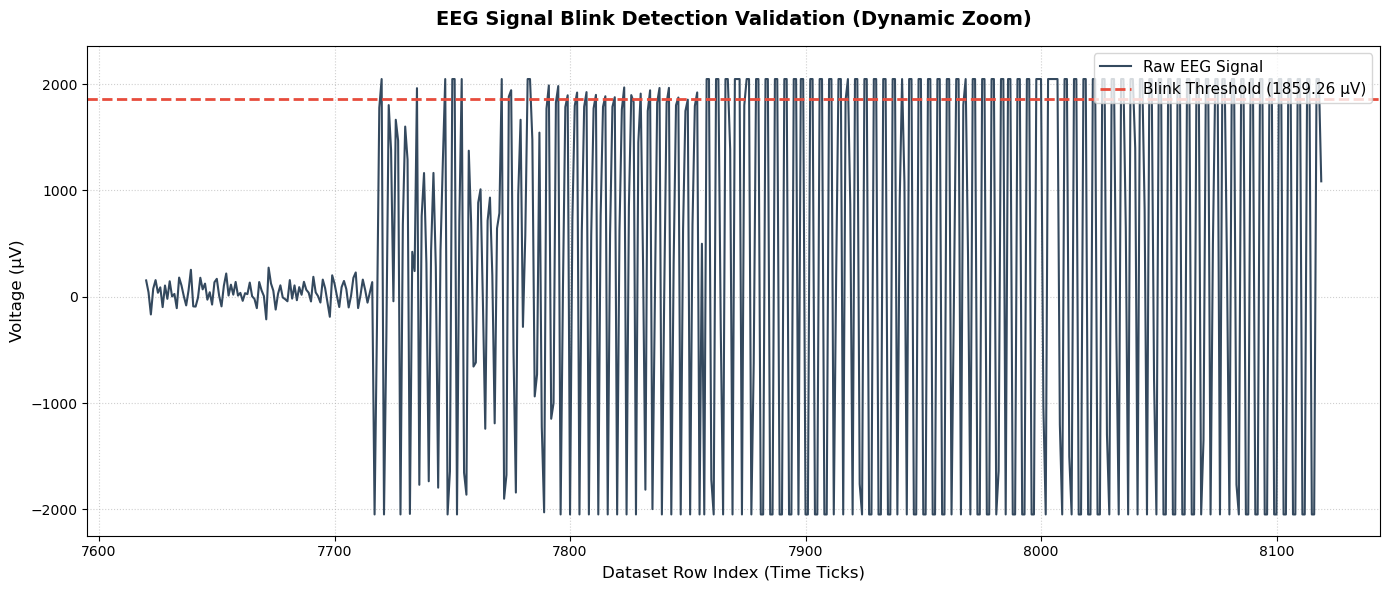

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Target the correct Raw EEG column (Index 4)
raw_eeg_signal = dataset[:, 4]  # <-- FIXED INDEX FROM 1 TO 4
threshold_value = 1859.26

# 2. Search the correct column to find exactly where the blink spikes are
spike_indices = np.where(raw_eeg_signal > threshold_value)[0]

if len(spike_indices) > 0:
    # Grab a window around the very first detected blink to show a great visual
    first_spike_row = spike_indices[0]
    start_row = max(0, first_spike_row - 100)
    end_row = min(len(dataset), first_spike_row + 400)
    print(f"Dynamically zooming into rows {start_row} to {end_row} to capture a real blink spike.")
else:
    # Fallback if no spikes cross it (just in case)
    start_row, end_row = 0, 500
    print("No spikes crossed the threshold. Showing the first 500 rows.")

# 3. Slice the data using our new dynamic window from the correct column
sample_window = raw_eeg_signal[start_row:end_row]
time_steps = range(start_row, end_row)

# 4. Create the plot canvas
plt.figure(figsize=(14, 6))
plt.plot(time_steps, sample_window, color='#34495e', label='Raw EEG Signal', linewidth=1.5)

# 5. Add the Threshold Line
plt.axhline(y=threshold_value, color='#e74c3c', linestyle='--', linewidth=2, 
            label=f'Blink Threshold ({threshold_value} μV)')

# 6. Dynamically set the Y-axis limits so the chaotic waves fill up the space nicely
y_min = np.percentile(sample_window, 1) - 200   
y_max = max(threshold_value + 500, np.max(sample_window) + 200)
plt.ylim(y_min, y_max)

# 7. Styling
plt.title('EEG Signal Blink Detection Validation (Dynamic Zoom)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Dataset Row Index (Time Ticks)', fontsize=12)
plt.ylabel('Voltage (μV)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('figure1.png', dpi=300, bbox_inches='tight')
plt.show()

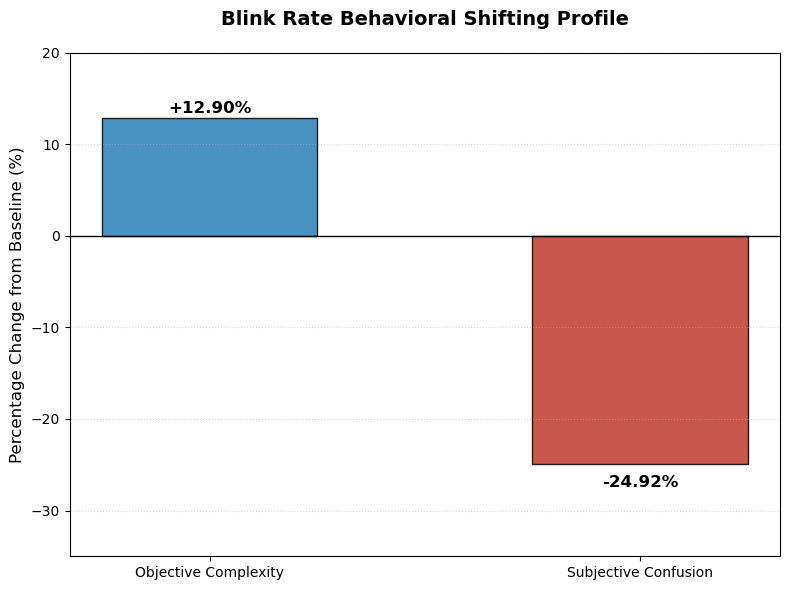

In [23]:
#  Visualization 2: Analysis 1 vs Analysis 2
# the positive increase in blinking caused by Objective Complexity vs. the sharp decrease in blinking caused by Subjective Confusion.

# 1. Define the metrics calculated from your prior analysis steps
conditions = ['Objective Complexity', 'Subjective Confusion']
percentage_shifts = [12.90, -24.92]  # Your calculated experimental results
bar_colors = ['#2980b9', '#c0392b']  # Blue for increase, Red for decrease

# 2. Build the bar structure
plt.figure(figsize=(8, 6))
bars = plt.bar(conditions, percentage_shifts, color=bar_colors, width=0.5, edgecolor='black', alpha=0.85)

# 3. Add a baseline line at 0%
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# 4. Dynamically print the percentage text above/below the corresponding bars
for bar in bars:
    height = bar.get_height()
    label_y = height + 1 if height >= 0 else height - 2
    plt.text(bar.get_x() + bar.get_width()/2., label_y,
             f'{height:+.2f}%',
             ha='center', va='center', fontsize=12, weight='bold')

# 5. Labeling and styling
plt.title('Blink Rate Behavioral Shifting Profile', fontsize=14, pad=20, weight='bold')
plt.ylabel('Percentage Change from Baseline (%)', fontsize=12)
plt.ylim(-35, 20)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Display the bar chart
plt.tight_layout()
plt.savefig('figure2.png', dpi=300, bbox_inches='tight')
plt.show()

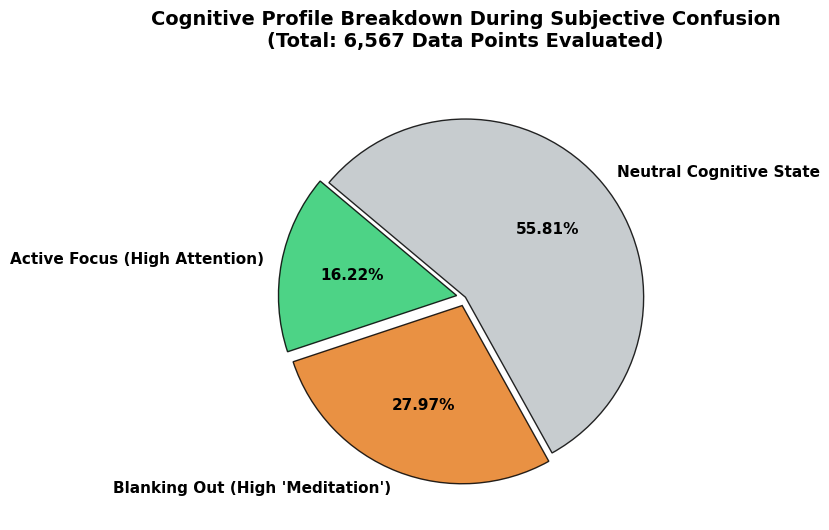

In [24]:
# Visualization 3: Cognitive State Timeline Distribution 
# Shows how the total subjective confusion (6,567 data points) is split between Active Focus, Blanking Out, and standard Neutral baseline states.

# 1. Calculate the remaining neutral baseline percentage so the pie chart hits 100% total
neutral_percentage = 100.0 - (16.22 + 27.97)

# 2. Set up data slices, labels, and specific distinct colors
slices = [16.22, 27.97, neutral_percentage]
labels = ['Active Focus (High Attention)', "Blanking Out (High 'Meditation')", 'Neutral Cognitive State']
pie_colors = ['#2ecc71', '#e67e22', '#bdc3c7']  # Green, Orange, Gray
explode_profile = (0.05, 0.05, 0)  # Slightly separate the two key active metrics

# 3. Build the pie chart
plt.figure(figsize=(8, 8))
plt.pie(slices, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=pie_colors, 
        explode=explode_profile,
        textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'alpha': 0.85})

# 4. Title and Presentation clean up
plt.title('Cognitive Profile Breakdown During Subjective Confusion\n(Total: 6,567 Data Points Evaluated)', 
          fontsize=14, pad=20, weight='bold')

# Display the pie chart
plt.tight_layout()
plt.savefig('figure3.png', dpi=300, bbox_inches='tight')
plt.show()